In [1]:
!pip install sentence-transformers matplotlib seaborn pandas scikit-learn

from sentence_transformers import SentenceTransformer, util
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 1. Sentences across 3 topics
sentences = [
    "The batsman hit a massive six over long-on.", "Virat Kohli scored a brilliant century in the final.", "The fielder took a stunning catch at the boundary.", # Cricket
    "Add a pinch of salt and sauté the onions until golden brown.", "Slow-cooking the meat ensures it remains tender and juicy.", "Garnish the pasta with fresh basil and grated parmesan.", # Cooking
    "Multi-factor authentication adds an extra layer of security.", "Phishing attacks often use deceptive emails to steal passwords.", "The firewall blocked a suspicious IP address from the network.", "Encrypting sensitive data prevents unauthorized access." # Cybersecurity
]

# 2. Load model and generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

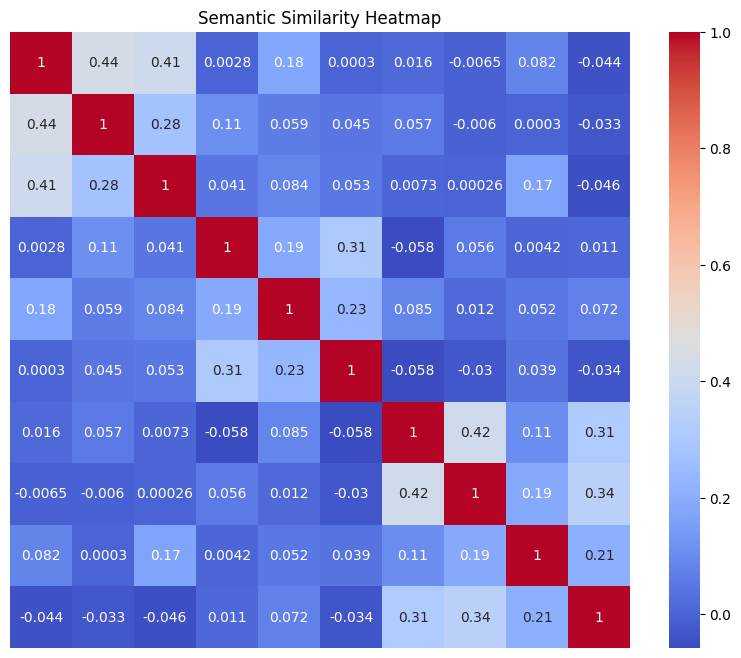

In [3]:
# 3. Compute 10x10 Cosine Similarity Matrix
sim_matrix = util.cos_sim(embeddings, embeddings).numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title("Semantic Similarity Heatmap")
plt.show()

In [4]:
# 4. New Query
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query)

# Compute similarity
cos_scores = util.cos_sim(query_embedding, embeddings)[0]

# Convert to numpy and then get the top 2 indices
# We use argsort() to get indices, then slice the last two, then reverse them
scores_np = cos_scores.cpu().numpy() if hasattr(cos_scores, 'cpu') else cos_scores.numpy()
top_results = np.argsort(scores_np)[-2:][::-1]

print(f"Query: {query}\n")
for idx in top_results:
    print(f"Similar Sentence: {sentences[idx]}")
    print(f"Similarity Score: {scores_np[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Similar Sentence: The batsman hit a massive six over long-on.
Similarity Score: 0.5465

Similar Sentence: Virat Kohli scored a brilliant century in the final.
Similarity Score: 0.4272

